# 48. Plotting helpers: `plot_dalitz`, `plot_square_dalitz`, `binned_data`, `plot_pulls`

**Objectives:**

- Plot a toy sample in ordinary Dalitz coordinates with `plot_dalitz`.
- Plot the same sample in Square-Dalitz coordinates with `plot_square_dalitz`.
- Get bin centers, counts, uncertainties and edges without plotting, using `binned_data`.
- Plot per-bin pulls from a `BinnedChi2Result` with `plot_pulls`.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and daughter
indices start at zero. This notebook generates its own toy data and does not reproduce a
published measurement.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede any numerical work: amplitudes use complex128.

import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant, Parameter, RealImag,
    Resonance, binned_data, generate_toy, plot_dalitz, plot_pulls,
    plot_square_dalitz,
)

## 1. A small model and a toy sample

A rho(770) plus a non-resonant term in `D+ -> pi- pi+ pi+`, the same style of model used
throughout the course. `generate_toy` produces an unweighted sample that can be histogrammed
directly.

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
components = [
    Resonance("rho", (0, 1), RealImag(1.0, 0.0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(0.5, 0.2), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=80, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

toy = generate_toy(
    model, 2000, parameters=truth, seed=48,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Toy sample: {toy.size} events")

Toy sample: 2000 events


## 2. `plot_dalitz`: ordinary Dalitz coordinates

`plot_dalitz` histograms two invariants (default `x="s13"`, `y="s23"`) in one call. Here the
generated pair is `(0, 1)` (`s12`), so `s12`/`s13` is the natural choice.

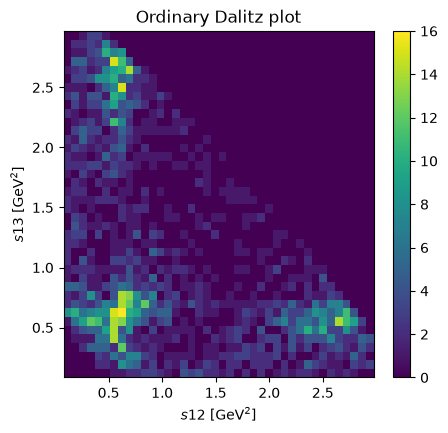

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_dalitz(toy, x="s12", y="s13", bins=40, ax=ax, title="Ordinary Dalitz plot")
plt.show()

## 3. `plot_square_dalitz`: Square-Dalitz coordinates

`plot_square_dalitz` takes the ordinary invariant sample and remaps it to `(m', theta')`
internally, given the mother mass, daughter masses and the pair that defines the square-Dalitz
transform.

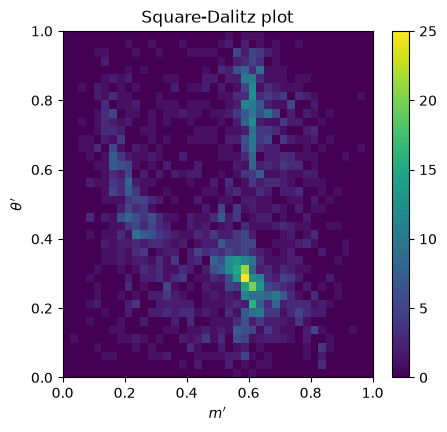

In [4]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_square_dalitz(
    toy, mother_mass=channel.parent_mass, masses=channel.daughter_masses, pair=(0, 1),
    bins=40, ax=ax, title="Square-Dalitz plot",
)
plt.show()

## 4. `binned_data`: bin contents without plotting

`binned_data` returns bin centers, counts, statistical uncertainties and edges directly, useful
when building a custom figure or exporting a 1D projection instead of using `plot_binned_data`.

In [5]:
centers, counts, uncertainties, edges = binned_data(np.asarray(toy.s12), bins=30)
print("n_bins:", len(centers))
print("first 5 centers:", centers[:5])
print("first 5 counts:", counts[:5])
print("first 5 uncertainties:", uncertainties[:5])

n_bins: 30
first 5 centers: [0.12809296 0.22458366 0.32107435 0.41756505 0.51405575]
first 5 counts: [ 75 116 116 133 210]
first 5 uncertainties: [ 8.66025404 10.77032961 10.77032961 11.53256259 14.49137675]


## 5. `plot_pulls` on a `BinnedChi2Result`

A quick fit gives a `FitSession`, whose `goodness_of_fit_projection` returns a `BinnedChi2Result`
that `plot_pulls` knows how to draw (a 1D bar plot with a shaded +-2 reference band).

valid=True  NLL=2317.828317
parameter                           value            error
NR.x                             0.506926        0.0204348
NR.y                             0.216069        0.0213085


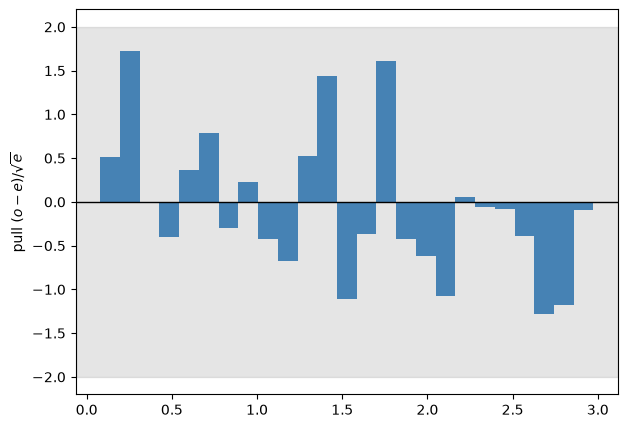

In [6]:
x = Parameter.coefficient("NR.x", 0.5, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.2, owner="NR", bounds=(-2, 2), step=0.02)
fit_components = [
    Resonance("rho", (0, 1), RealImag(1.0, 0.0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
fit_model = DecayModel(
    channel, fit_components, normalization_method="square-dalitz",
    normalization_resolution=80, normalization_pair=(0, 1),
)
session = FitSession(fit_model, toy)
result = session.fit({"NR.x": 0.4, "NR.y": 0.3}, simplex=True, ncall=3000)
assert result.valid
session.print_result(result)

gof = session.goodness_of_fit_projection(result, "s12", bins=25)
plot_pulls(gof)
plt.show()

## Summary and exercises

1. Try `log_scale=True` in `plot_dalitz`/`plot_square_dalitz` for a wide dynamic range.
2. Compare `binned_data` on weighted vs. unweighted samples: weighted uncertainties use
   `sqrt(sum w^2)` per bin instead of the Poisson `sqrt(N)`.
3. Call `session.goodness_of_fit_chi2(result, "s12", "s13", bins=15)` and pass the 2D result to
   `plot_pulls`; it dispatches automatically to a diverging heatmap.

Return to the [course guide](TUTORIALS.md).